In [1]:
import pandas as pd
import numpy as np

# Customer Churn Prediction – Exploratory Data Analysis (EDA)

## Objective
Explore and understand the customer churn dataset to prepare it for machine learning.

## Steps
1. Load dataset
2. Inspect data
3. Handle missing values
4. Encode categorical features
5. Prepare features and target

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../Data/Telco-Customer-Churn.csv")

# Get first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Checking basic info about the dataset
df.info()

# Summary statistics for numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
# Drop ID
df = df.drop(columns=["customerID"])

# TotalCharges is a float quantity when we see in table but when we check data type it is stored as object
# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [5]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
# Handle missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Get dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [7]:
# Encode "Yes" to 1 and "No" to 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Get the target distribution
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [8]:
# Make X for features
X = df.drop(columns=["Churn"])

# Make y for target
y = df["Churn"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Get categorical column names
cat_cols = X.select_dtypes(include="object").columns

# Get numerical column names
num_cols = X.select_dtypes(exclude="object").columns

# Make a preprocessor for feature transformation
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Build a pipeline for Logistic Regression
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

# Cross-validation
log_cv_scores = cross_val_score(
    log_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression CV ROC-AUC:", log_cv_scores.mean())

# Fit on training data
log_model.fit(X_train, y_train)

C:\Users\USER\anaconda3\envs\churn-ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\USER\anaconda3\envs\churn-ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/pre

Logistic Regression CV ROC-AUC: 0.8449809801174538


C:\Users\USER\anaconda3\envs\churn-ml\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Build a pipeline for RandomForest
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ))
])

# Cross-validation
rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Random Forest CV ROC-AUC:", rf_cv_scores.mean())

# Fit on training data
rf_model.fit(X_train, y_train)

Random Forest CV ROC-AUC: 0.843850179344452


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [14]:
from xgboost import XGBClassifier

# Build a pipeline for XGB
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ))
])

# Cross-validation
xgb_cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("XGBoost CV ROC-AUC:", xgb_cv_scores.mean())

# Fit on training data
xgb_model.fit(X_train, y_train)

XGBoost CV ROC-AUC: 0.8453651177085352


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Logistic Regression Performance
Evaluation Metrics at Threshold = 0.4
----------------------------------------
Accuracy: 0.7785663591199432
Precision: 0.5707762557077626
Recall: 0.6684491978609626
ROC-AUC: 0.8426515797359787


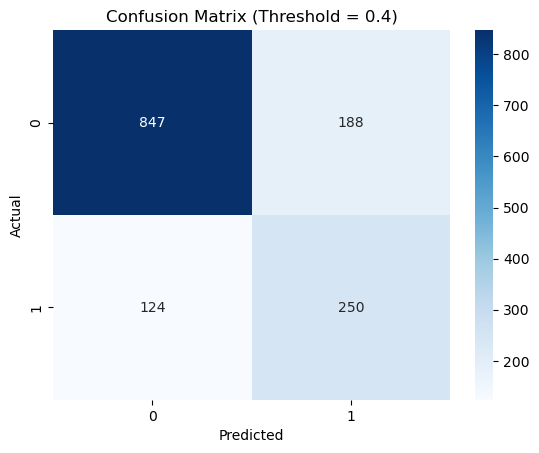

Random Forest Performance
Evaluation Metrics at Threshold = 0.4
----------------------------------------
Accuracy: 0.7934705464868701
Precision: 0.6050632911392405
Recall: 0.6390374331550802
ROC-AUC: 0.840091451600403


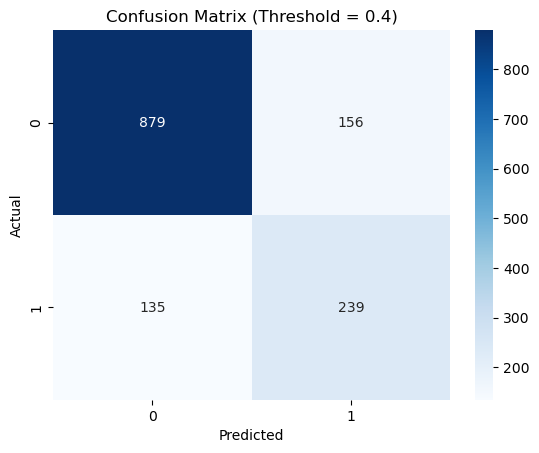

XGBoost Performance
Evaluation Metrics at Threshold = 0.4
----------------------------------------
Accuracy: 0.7835344215755855
Precision: 0.5843520782396088
Recall: 0.6390374331550802
ROC-AUC: 0.8437030148027591


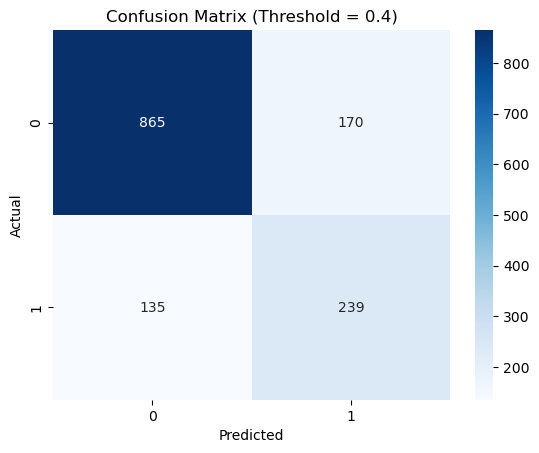

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

#Define an evaluation model with custom threshold
def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = (y_prob >= threshold).astype(int)

    print(f"Evaluation Metrics at Threshold = {threshold}")
    print("-"*40)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (Threshold = {threshold})')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

print("Logistic Regression Performance")
evaluate_model(log_model, X_test, y_test, threshold=0.4)

print("Random Forest Performance")
evaluate_model(rf_model, X_test, y_test, threshold=0.4)

print("XGBoost Performance")
evaluate_model(xgb_model, X_test, y_test, threshold=0.4)

In [16]:
# Get the trained Logistic Regression model from your pipeline
log_coef = log_model.named_steps['model'].coef_[0]

# Handling OneHotEncoded features
ohe = log_model.named_steps['preprocessor'].named_transformers_['cat']
ohe_features = list(ohe.get_feature_names_out())
num_features = X.select_dtypes(exclude='object').columns.tolist()
all_features = np.concatenate([ohe_features, num_features])

# Creating a Series for feature importance
log_feat_imp = pd.Series(log_coef, index=all_features).sort_values(key=abs, ascending=False)

# Show top 10
log_feat_imp[:10]

Contract_Two year                -0.733721
Contract_Month-to-month           0.642426
InternetService_DSL              -0.397647
InternetService_Fiber optic       0.380882
PaperlessBilling_No              -0.262265
MultipleLines_No                 -0.244918
PaymentMethod_Electronic check    0.236142
OnlineSecurity_Yes               -0.221559
PhoneService_Yes                 -0.211664
OnlineSecurity_No                 0.204793
dtype: float64

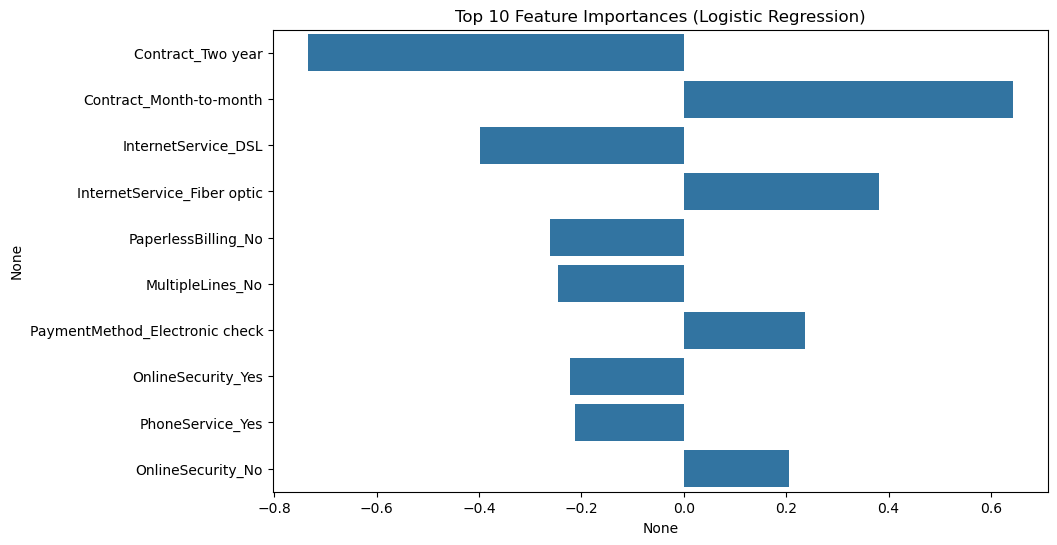

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x=log_feat_imp[:10], y=log_feat_imp[:10].index)
plt.title('Top 10 Feature Importances (Logistic Regression)')
plt.savefig("../outputs/top_10_features_affecting_churn.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [18]:
# Features that increase churn (positive coefficients)
positive_features = log_feat_imp[log_feat_imp > 0].sort_values(ascending=False)

# Features that decrease churn (negative coefficients)
negative_features = log_feat_imp[log_feat_imp < 0].sort_values()

In [19]:
top_positive = positive_features[:10]

print("Top 10 features increasing churn:")
print(top_positive)

Top 10 features increasing churn:
Contract_Month-to-month           0.642426
InternetService_Fiber optic       0.380882
PaymentMethod_Electronic check    0.236142
OnlineSecurity_No                 0.204793
TechSupport_No                    0.179263
SeniorCitizen                     0.143907
PaperlessBilling_Yes              0.110734
StreamingTV_Yes                   0.097841
StreamingMovies_Yes               0.097739
OnlineBackup_No                   0.081236
dtype: float64


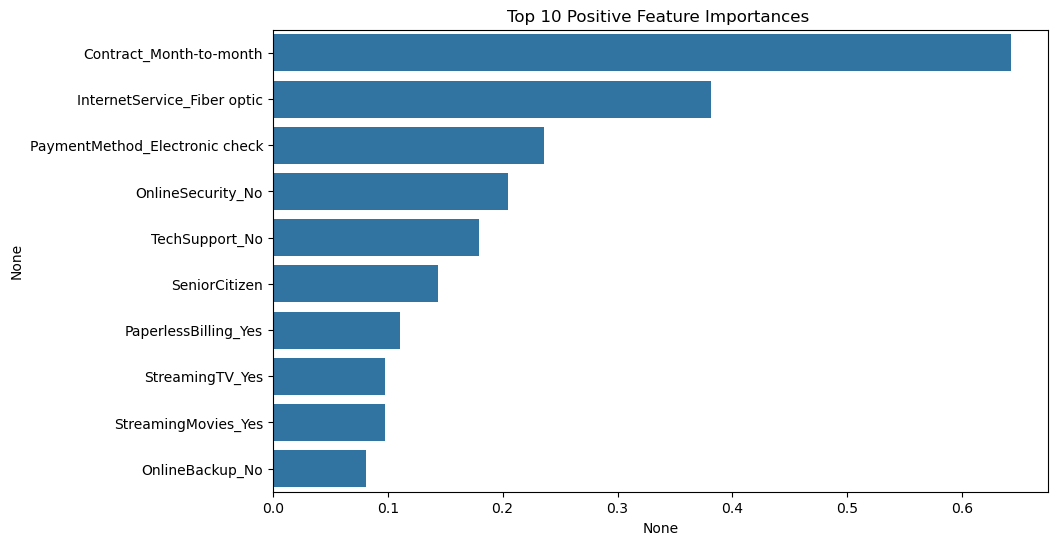

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_positive, y=top_positive.index)
plt.title('Top 10 Positive Feature Importances ')
plt.savefig("../outputs/top_10_features_increasing_churn.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [21]:
top_negative = negative_features[:10]

print("\nTop 10 features reducing churn:")
print(top_negative)


Top 10 features reducing churn:
Contract_Two year                         -0.733721
InternetService_DSL                       -0.397647
PaperlessBilling_No                       -0.262265
MultipleLines_No                          -0.244918
OnlineSecurity_Yes                        -0.221559
PhoneService_Yes                          -0.211664
TechSupport_Yes                           -0.196028
Dependents_Yes                            -0.188095
PaymentMethod_Credit card (automatic)     -0.172937
PaymentMethod_Bank transfer (automatic)   -0.142943
dtype: float64


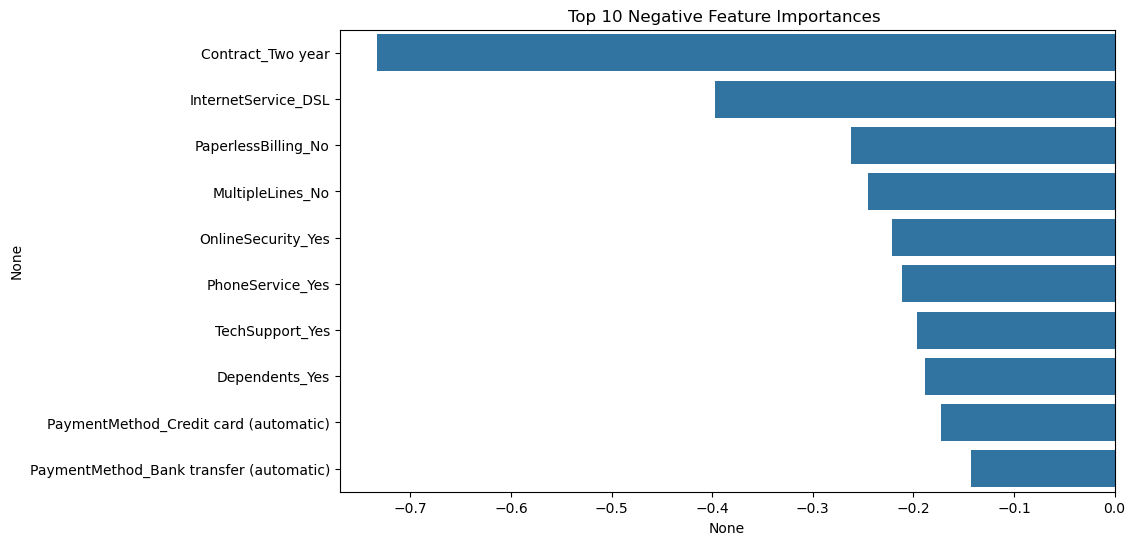

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_negative, y=top_negative.index)
plt.title('Top 10 Negative Feature Importances ')
plt.savefig("../outputs/top_10_features_decreasing_churn.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [23]:
# Using Logistic Regression
y_prob = log_model.predict_proba(X_test)[:,1]

# Add probabilities to a DataFrame
pred_df = X_test.copy()
pred_df['Churn_Prob'] = y_prob
pred_df['Actual_Churn'] = y_test.values

In [24]:
#Defining a Risk Bucket
def churn_risk_bucket(prob):
    if prob >= 0.55:
        return 'High'
    elif prob >= 0.35:
        return 'Medium'
    else:
        return 'Low'

pred_df['Risk_Bucket'] = pred_df['Churn_Prob'].apply(churn_risk_bucket)

In [25]:
pred_df["Risk_Bucket"] = [churn_risk_bucket(prob) for prob in y_prob]

In [26]:
pred_df['Risk_Bucket'].value_counts(normalize=True)

Risk_Bucket
Low       0.655075
High      0.180270
Medium    0.164656
Name: proportion, dtype: float64

In [27]:
pred_df.to_csv("../outputs/churn_predictions.csv", index=False)

In [28]:
import joblib
import os

save_path = os.path.abspath("../models/churns_model.joblib")
print("Saving to:", save_path)

os.makedirs(os.path.dirname(save_path), exist_ok=True)

joblib.dump(log_model, save_path)

Saving to: C:\Users\USER\OneDrive\Documents\customer-churn-ml\models\churns_model.joblib


['C:\\Users\\USER\\OneDrive\\Documents\\customer-churn-ml\\models\\churns_model.joblib']